# HW4: Palmer Penguins — Summary Statistics & Plots
# Kaiden Chacon

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [3]:
# a
print(penguins.shape)

(344, 8)


In [6]:
# b
print(penguins.info())

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB
None


In [7]:
# c
print(penguins.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [8]:
# d
print(penguins['species'].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [9]:
# Your code here
penguins_clean = penguins.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex'])
print(penguins_clean.shape)

(333, 8)


### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [26]:
# a
penguins_clean.describe().iloc[:, :4]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057
std,5.469,1.969,14.016,805.216
min,32.100,13.100,172.000,2700.000
25%,39.500,15.600,190.000,3550.000
50%,44.500,17.300,197.000,4050.000
75%,48.600,18.700,213.000,4775.000
max,59.600,21.500,231.000,6300.000


In [34]:
penguins_clean.groupby(by='species')[['bill_length_mm', 'bill_depth_mm', 
    'flipper_length_mm', 'body_mass_g']].agg(['mean', 'std'])

bill_length_mm        bill_depth_mm        flipper_length_mm         \
                    mean    std          mean    std              mean    std   
species                                                                         
Adelie            38.824  2.663        18.347  1.219           190.103  6.522   
Chinstrap         48.834  3.339        18.421  1.135           195.824  7.132   
Gentoo            47.568  3.106        14.997  0.986           217.235  6.585   

          body_mass_g           
                 mean      std  
species                         
Adelie       3706.164  458.620  
Chinstrap    3733.088  384.335  
Gentoo       5092.437  501.476

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [41]:
# a
PenguinsMeanCount = penguins_clean.groupby(by=['species', 'sex'])[['bill_length_mm', 
                                               'bill_depth_mm', 
                                               'flipper_length_mm', 
                                               'body_mass_g']].agg(['mean', 'count'])
PenguinsMeanCount

bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938.971    34  
Gentoo    female    58    4679.741    58  
          male      61    5484.836    61

In [54]:
# b
PenguinsMeanCount.loc[PenguinsMeanCount[('body_mass_g', 'mean')].idxmax(), :]

bill_length_mm     mean       49.474
                   count      61.000
bill_depth_mm      mean       15.718
                   count      61.000
flipper_length_mm  mean      221.541
                   count      61.000
body_mass_g        mean     5484.836
                   count      61.000
Name: (Gentoo, male), dtype: float64

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [98]:
# a
tot_corr = penguins_clean[['bill_length_mm', 
                'bill_depth_mm', 
                'flipper_length_mm', 
                'body_mass_g']].corr()
tot_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.229,0.653,0.589
bill_depth_mm,-0.229,1.000,-0.578,-0.472
flipper_length_mm,0.653,-0.578,1.000,0.873
body_mass_g,0.589,-0.472,0.873,1.000


In [97]:
#b
species_corr = penguins_clean.groupby(by='species')[['bill_length_mm', 
                'bill_depth_mm', 
                'flipper_length_mm', 
                'body_mass_g']].corr()
species_corr

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   

                             body_mass_g  
species                                   
Adelie    bill_length_mm           0.544  
          bill_depth_mm            0.580  
          flipper_length_mm        0.465  
          body_mass_g              1.000  
Chinstrap bill_length_mm           0.514  
          bill_depth_mm            0.604  
          flipper_length_mm        0.642  
          body_mass_g              1.000  
Gentoo    bill_length_mm           0.667  
          bill_depth_mm            0.723  
          flipper_length_mm        0.711  
          body_mass_g              1.000

The data shows Simpson's Paradox for bill depths and bill length, filpper length and bill depth, and body mass and bill depth. This is because for each of the species correlation matricies all the values are positive, though when looking at the correlation for all the species those relationships because negative.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


Text(0.5, 1.0, 'Body Mass Distribution of Species')

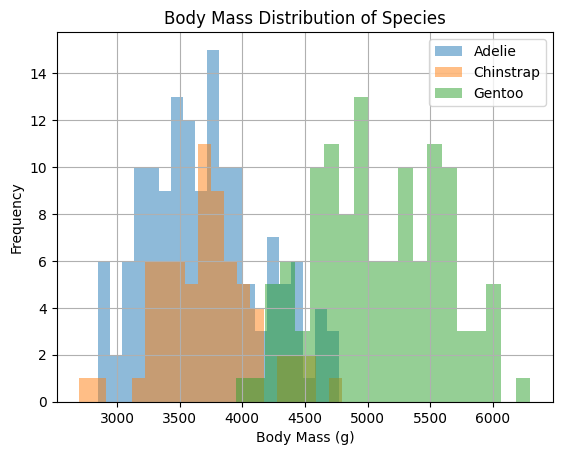

In [83]:
for species, group in penguins_clean.groupby('species'):
    group['body_mass_g'].hist(alpha=0.5, label=species, bins=20)
plt.legend()
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Body Mass Distribution of Species')

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

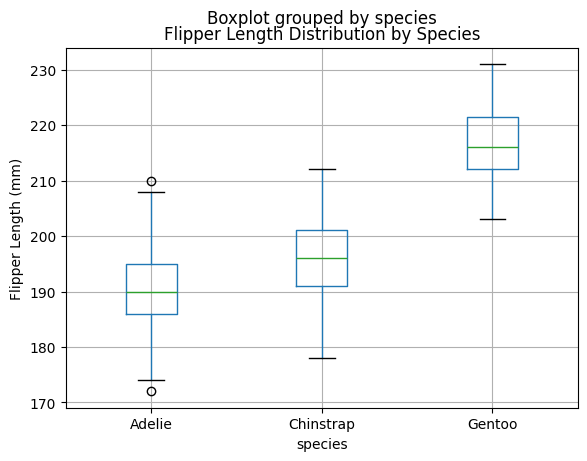

In [85]:
penguins_clean.boxplot(column='flipper_length_mm', by='species')
plt.title('Flipper Length Distribution by Species')
plt.ylabel('Flipper Length (mm)')
plt.show()

Observing the graph it is clear that the mean length of the flippers of the Gentoo species ($\approx$ 215mm) is significantly larger than that of the Adelie ($\approx$ 190mm) and the Chinstrap ($\approx$ 195mm). The spread of the distribution of flipper length is consistent among the species as the IQR for each is about $\approx$ 10mm though the ranges differ slightly as for the Adelie and Chinstrap the range is about 35mm for the Gentoo the range is about 30mm.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

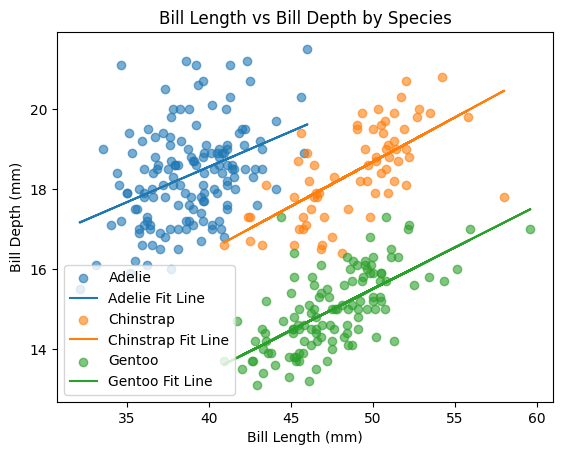

In [ ]:
for species, group in penguins_clean.groupby('species'):
    data = group[['bill_length_mm', 'bill_depth_mm']]
    x = data['bill_length_mm']
    y = data['bill_depth_mm']
    plt.scatter(x, y, label=species, alpha=0.6)

    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, label=f'{species} Fit Line')


plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Bill Length vs Bill Depth by Species')
plt.legend()
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

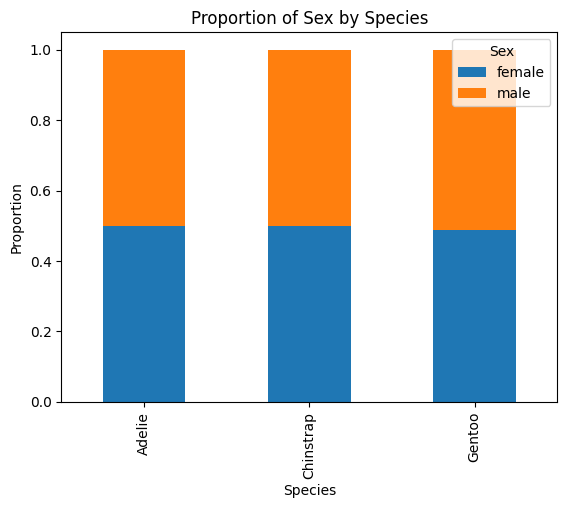

In [95]:
data = penguins_clean.groupby('species')['sex'].value_counts(normalize=True).unstack()
data.plot(kind='bar', stacked=True)
plt.title('Proportion of Sex by Species')
plt.xlabel('Species')
plt.ylabel('Proportion')
plt.legend(title='Sex')
plt.show()